## Projeto FLY

### Indicadores

### Gráficos

### Carteira e Rebalanceamento

### Análise de Portfolio

## Alchemy


In [ ]:
# Jupyter cell: Initialize and optimize SQLite in FLY

# 1) Imports
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker

from infrastructure.config import Config

In [ ]:
# 2) Load application configuration
#    Adjust constructor as needed (e.g., passing path to config file or env vars)
config = Config()

In [ ]:
# 3) Create the SQLAlchemy engine with thread-safe and future settings
engine = create_engine(
    config.database.connection_string,
    connect_args={"check_same_thread": False},  # allow multi-thread access
    future=True,
)

In [ ]:
# 4) Execute SQLite PRAGMAs for performance & integrity
with engine.connect() as conn:  # type: ignore
    conn.execute(text("PRAGMA wal_checkpoint"))  # type: ignore

    # ou, se preferir garantir que todo o WAL seja aplicado e truncado:
    conn.execute(text("PRAGMA wal_checkpoint(FULL)"))  # type: ignore
    conn.execute(text("PRAGMA wal_checkpoint(RESTART)"))  # type: ignore
    conn.execute(text("PRAGMA wal_checkpoint(TRUNCATE)"))  # type: ignore
    conn.execute(text("PRAGMA optimize"))  # type: ignore # Run internal optimizations
    conn.execute(text("PRAGMA journal_mode=WAL"))  # type: ignore # Write-Ahead Logging
    conn.execute(text("PRAGMA synchronous=FULL"))  # type: ignore # Full disk sync for safety
    conn.execute(text("PRAGMA foreign_keys=ON"))  # type: ignore # Enforce FK constraints
    conn.execute(text("PRAGMA temp_store=MEMORY"))  # type: ignore # RAM for temp tables
    conn.execute(text("PRAGMA cache_size=-65536"))  # type: ignore # 64 MB cache

In [ ]:
# 5) Create a session factory for ORM transactions
Session = sessionmaker(  # type: ignore
    bind=engine,  # type: ignore
    autoflush=True,
    expire_on_commit=True,
)

In [ ]:
# 6) (Optional) Inspect existing tables
with Session() as session:  # type: ignore
    result = session.execute(text("SELECT name FROM sqlite_master WHERE type='table';"))  # type: ignore
    tables = [row[0] for row in result]
    print("⏺️ Tables in database:", tables)

## YFINANCE

In [ ]:
import yfinance as yf

tickers = ["LREN3.SA", "VALE3.SA"]

# Histórico diário
df = yf.download(tickers, start="1960-01-01", interval="1d",)


In [ ]:
df

### Preço atual e variação intraday

In [ ]:
info = yf.Tickers(" ".join(tickers))

for t in tickers:
    data = info.tickers[t].info
    print(
        t,
        "Preço:", data.get("regularMarketPrice"),
        "Variação:", data.get("regularMarketChange"),
        "Variação %:", data.get("regularMarketChangePercent"),
    )


### Dados fundamentais

In [ ]:
data = {}

for t in tickers:
    tk = yf.Ticker(t)
    info = tk.info
    data[t] = {
        "Nome": info.get("longName"),
        "Setor": info.get("sector"),
        "Indústria": info.get("industry"),
        "Valor de Mercado": info.get("marketCap"),
        "P/L": info.get("trailingPE"),
        "Lucro por Ação (EPS)": info.get("trailingEps"),
        "Dividend Yield": info.get("dividendYield"),
        "Beta": info.get("beta"),
        "Moeda": info.get("currency"),
    }

import pandas as pd
df = pd.DataFrame(data).T
df


In [ ]:

t = yf.Ticker("VAle3.SA")

# Retorna todos os campos de fundamentos
info = t.info

# Converter para DataFrame para melhor leitura
df = pd.DataFrame(info.items(), columns=["Campo", "Valor"])
df

### Dados financeiros estruturados

In [ ]:
import yfinance as yf

tickers = ["LREN3.SA"]

for t in tickers:
    tk = yf.Ticker(t)

    print(f"\n--- {t} ---")

    # Demonstrativos de resultado (anual e trimestral)
    print("Income Statement (anual):")
    print(tk.financials)

    print("\nIncome Statement (trimestral):")
    print(tk.quarterly_financials)

    # Balanço patrimonial
    print("\nBalance Sheet (anual):")
    print(tk.balance_sheet)

    print("\nBalance Sheet (trimestral):")
    print(tk.quarterly_balance_sheet)

    # Fluxo de caixa
    print("\nCashflow (anual):")
    print(tk.cashflow)

    print("\nCashflow (trimestral):")
    print(tk.quarterly_cashflow)


In [ ]:
tk.eps_revisions

## BCB Series

### BCB Series Download

In [ ]:
import requests
from bs4 import BeautifulSoup
import time
import csv
import os
import re

In [ ]:
# --- FILE NAMES
csv_file_name = 'bcb_series_completas2.csv'
csv_headers = [
        'Codigo', 'Nome_Completo', 'Unidade', 'Periodicidade', 'Data_Inicio', 'Ultimo_Valor', 'Fonte'
    ]

# --- URLs de Ação (Sequência Mínima) ---
BASE_URL = "https://www3.bcb.gov.br/sgspub"
SEARCH_POST_URL = f"{BASE_URL}/localizarseries/localizarSeries.paint?method=localizarSeriesPorPesquisaAvancada"
PAGINATION_URL = f"{BASE_URL}/localizarseries/localizarSeries.do?method=getPagina"

METADATA_URL = f'{BASE_URL}/localizarseries/localizarSeries.do?method=recuperarMetadadosPorDocn'
METADADOS_BASICOS_URL = f'{BASE_URL}/JSP/consultarmetadados/cmiDadosBasicos.jsp'
METADADOS_COMPLETOS_URL = f'{BASE_URL}/JSP/consultarmetadados/cmiMetadados.jsp'

# --- HEADERS ---
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36',
    'Content-Type': 'application/x-www-form-urlencoded',
}

# --- PAYLOADS ---
INITIAL_PAYLOAD = {
    'codigos': '', 'periodicidade': '0', 'fonte': '0', 'unidadePadrao': '0',
    'filtro': '0', 'chkClassificacao': 'on', 'txtPesquisa': '', 'ordem1': '0',
    'sentido1': '0', 'ordem2': '0', 'sentido2': '0', 'ordem3': '0',
    'sentido3': '0', 'hdCodigos': '', 'hdGrupos': '', 'hdTipoPesquisa': '9',
    'hdTipoOrdenacao': '0', 'hdPeriodicidade': 'Todas', 'hdFonte': 'Todas',
    'hdUnidadePadrao': 'Todas', 'hdFiltro': ''
}
BASE_PAYLOAD_PAGINATION = {
    'periodicidade': '0', 'codigo': '', 'fonte': '341', 'texto': '',
    'hdFiltro': '', 'hdOidGrupoSelecionado': '', 'hdSeqGrupoSelecionado': '',
    'hdNomeGrupoSelecionado': '', 'hdTipoPesquisa': '9', 'hdTipoOrdenacao': '0',
    'hdPeriodicidade': 'Todas', 'hdSeriesMarcadas': '', 'hdMarcarTodos': '',
    'hdFonte': '', 'hdOidSerieMetadados': '', 'hdNumeracao': '',
    'hdOidSeriesLocalizadas': '',
    'linkRetorno': '/sgspub/consultarvalores/telaCvsSelecionarSeries.paint',
    'linkCriarFiltros': '/sgspub/manterfiltros/telaMfsCriarFiltro.paint'
}
METADATA_PAYLOAD_BASE = { 
    # ... (Campos do seu payload de metadados aqui) ...
    'hdOidSerieMetadados': '', # OBRIGATÓRIO: Código da Série
    'linkRetorno': '/sgspub/consultarvalores/telaCvsSelecionarSeries.paint',
    'linkCriarFiltros': '/sgspub/manterfiltros/telaMfsCriarFiltro.paint'
}
HEADERS_TO_IGNORE = ["Sumário Metodológico", "Formatos de Divulgação", "Summary Methodology", "Dissemination Formats", ]


In [ ]:
def clean_cell(text):
    if not isinstance(text, str):
        return text

    text = text.replace('\x96', '–').replace('\x93', '"').replace('\x94', '"')
    text = text.replace('\xa0', ' ') # Remove Non-breaking space
    text = text.replace('*', '') # <--- REMOVE O ASTERISCO DE QUALQUER CHAVE OU VALOR

    # 2. Regex: Substitui qualquer sequência de whitespace por um único espaço
    text= re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
def save_to_csv(data_list, csv_file_name):
    if not data_list:
        print("Nenhum dado para salvar em CSV.")
        return

    csv_headers = []

    # 2. Set para garantir a unicidade e rapidez na checagem
    seen_fields = set()

    # Itera sobre cada dicionário de metadados
    for series_dict in data_list:
        # Itera sobre as chaves do dicionário (a ordem de iteração é importante)
        for field in series_dict.keys():
            if field not in seen_fields:
                # Adiciona à lista de cabeçalhos e ao set de controle
                csv_headers.append(field)
                seen_fields.add(field)

    try:
        with open(csv_file_name, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=csv_headers, quoting=csv.QUOTE_ALL, restval='')

            writer.writeheader()
            writer.writerows(data_list)

        print(f"Total de {len(data_list)} séries salvas em '{csv_file_name}'.")

    except Exception as e:
        print(f"ERRO ao salvar o arquivo CSV: {e}")

In [ ]:
def parse_page_data(html_content):
    """Extrai os dados da tabela HTML, retornando uma lista de dicionários."""
    soup = BeautifulSoup(html_content, 'html.parser')

    table = soup.find('table', id='tabelaSeries')
    if not table:
        return []

    series_data = []

    # Busca todas as linhas (<tr>) diretamente na <table>.
    all_rows = table.find_all('tr')

    for row in all_rows:
        cells = row.find_all('td', recursive=False)

        # Ignora linhas de cabeçalho e linhas incompletas.
        if len(cells) < 10:
            continue

        # Mapeamento dos dados
        data = {
            'Codigo': clean_cell(cells[1].text),
            'Nome_Completo': clean_cell(cells[2].text),
            'Unidade': clean_cell(cells[3].text),
            'Periodicidade': clean_cell(cells[4].text),
            'Data_Inicio': clean_cell(cells[5].text),
            'Ultimo_Valor': clean_cell(cells[6].text),
            'Fonte': clean_cell(cells[7].text),
        }
        series_data.append(data)

    return series_data

In [ ]:
def fetch_series(series, soup_basico, metadata_completo):
    metadata = {}
    metadata_basico = soup_basico.find_all('table')
    for t, table in enumerate(metadata_basico):
        rows = table.find_all('tr')
        for r, row in enumerate(rows):
            # Buscar células de dados (<td>)
            cells = row.find_all('td')
            # Assume a estrutura de 4 colunas (Rótulo, Valor, Rótulo, Valor)
            for i in range(0, len(cells), 2):
                if i + 1 < len(cells):
                    label = clean_cell(cells[i].text)
                    value = clean_cell(cells[i+1].text)
                    if label:
                        metadata[label] = value

    last_cell = None
    for t, table in enumerate(metadata_completo):
        rows = table.find_all('tr')
        for r, row in enumerate(rows):
            cells = row.find_all('td')
            cell_count = len(cells)
            if cell_count > 2:
                continue
            elif cell_count == 2:
                # Condição: Rótulo e Valor na mesma linha (Estrutura 2-col)
                # O bloco anterior de iteração foi removido
                label = clean_cell(cells[0].text)
                value = clean_cell(cells[1].text)

                if label and label not in HEADERS_TO_IGNORE:
                    metadata[label] = value

                # Zera o last_cell, pois um par K:V completo foi encontrado
                last_cell = None 

            elif cell_count == 1:
                # Condição: Máquina de Estados para conteúdo multi-linha (Estrutura 1-col)
                content = clean_cell(cells[0].text)

                # 1. Se existe uma chave pendente (last_cell):
                if last_cell:
                    # O 'content' atual é o VALOR para a chave pendente.
                    # Se o conteúdo estiver vazio, armazena vazio. Se tiver texto longo, armazena o texto limpo.
                    metadata[last_cell] = content
                    # Zera o estado após encontrar o valor
                    last_cell = None 

                # 2. Se NÃO existe chave pendente e o 'content' é um rótulo válido:
                elif content and content not in HEADERS_TO_IGNORE:
                    # O 'content' é um novo rótulo (chave) que espera um valor na próxima linha
                    last_cell = content
    series.update(metadata)

    return series


In [ ]:
def scrape_all_series(page_num=1):
    """Executa o scraping completo e retorna a lista de dicionários de séries."""
    all_data = []
    session = requests.Session()
    max_retries = 3

    # --- 1. ESTABELECIMENTO DE SESSÃO ---
    response_session = session.get(BASE_URL)
    response_initial = session.post(SEARCH_POST_URL, data=INITIAL_PAYLOAD, headers=HEADERS, timeout=30)

    # --- 2. LOOP DE PAGINAÇÃO ---
    page_num = page_num or 1
    previous_content_hash = hash(response_initial.text)
    previous_content_hash = hash(response_session.text)

    while True:
        current_payload = BASE_PAYLOAD_PAGINATION.copy()
        current_payload['hdNumPagina'] = str(page_num)

        retries = 0
        current_html = ""

        # Tenta o request de paginação
        while retries < max_retries:
            try:
                response_page = session.post(PAGINATION_URL, data=current_payload, headers=HEADERS, timeout=10)
                response_page.raise_for_status() 
                current_html = response_page.text
                break
            except requests.exceptions.RequestException:
                retries += 1
                time.sleep(3)

        if retries == max_retries:
            print(f"Falha na página {page_num}. Abortando.")
            break

        # Verifica se o conteúdo é o mesmo da página anterior (indicador de fim)
        current_content_hash = hash(current_html.replace('\r\n', ''))
        if current_content_hash == previous_content_hash:
            print(f"Conteúdo da página {page_num} idêntico. Fim da paginação.")
            break

        previous_content_hash = current_content_hash

        data_page = parse_page_data(current_html)

        if not data_page:
            print(f"Página {page_num} não retornou linhas. Encerrando.")
            break

        series_data = []
        for s, series in enumerate(data_page):
            payload = METADATA_PAYLOAD_BASE.copy()
            codigo = series['Codigo'] # Inserindo o código dinamicamente
            fonte = series['Fonte']
            nome = series['Nome_Completo']
            payload['hdOidSerieMetadados'] = codigo

            print(f"Página {page_num}-{(len(all_data)+s)} {codigo}-{fonte}-{nome}")
            session.post(METADATA_URL, data=payload, headers=HEADERS, timeout=10)
            response_basico = session.get(METADADOS_BASICOS_URL, headers=HEADERS, timeout=10)
            soup_basico = BeautifulSoup(response_basico.text, 'html.parser')

            response_completo = session.get(METADADOS_COMPLETOS_URL, headers=HEADERS, timeout=10)
            soup_completo = BeautifulSoup(response_completo.text, 'html.parser')
            metadata_completo = soup_completo.find_all('table')

            updated_series = fetch_series(series, soup_basico, metadata_completo)
            series_data.append(updated_series) # Usa append() para adicionar o dicionário)

        all_data.extend(series_data)
        if all_data is not None:
            save_to_csv(all_data, csv_file_name)
            print(f"Página {page_num} capturada. Total geral: {len(all_data)}")
        else:
            print("Processo de scraping falhou. Verifique as mensagens de erro acima.")

        page_num += 1
        # time.sleep(0.3)

    print("\nColeta finalizada.")
    return all_data

In [ ]:
# 1. Executa o scraping e armazena o resultado
bcb_series = scrape_all_series()

# 2. Salva a lista em CSV
if bcb_series is not None:
    save_to_csv(bcb_series, csv_file_name)
else:
    print("Processo de scraping falhou. Verifique as mensagens de erro acima.")

In [ ]:
df = pd.read_csv(r"D:\Fausto Stangler\Documentos\Python\FLY\bcb_series_completas.csv", dtype=str, )


In [ ]:
fontes = df['Fonte'].unique()
fontes

In [ ]:
dfs = {}
for fonte in fontes:
    mask = df['Fonte'] == fonte
    dfs[fonte] = df[mask][['Codigo', 'Short name', ]].drop_duplicates()

In [ ]:
df['Fonte'] == 'FGV'

In [ ]:
mask = df['Fonte'] == 'FGV'
df[mask]

### BCB Series CSV

In [53]:
import pandas as pd
import re
import os


In [7]:
csv_file = r"D:\Fausto Stangler\Documentos\Python\FLY\bcb_series_completas.csv"
df = pd.read_csv(csv_file, dtype=str, low_memory=False)
df['Codigo'] = df['Codigo'].astype('Int64')
cols = ['Codigo', 'Fonte', 'Short name', 'Full name', 'Periodicity', 'Ultimo_Valor', 'Series type', 'Subject chain']
df = df[cols]
df

,Codigo,Fonte,Short name,Full name,Periodicity,Ultimo_Valor,Series type,Subject chain
0,1,Sisbacen PTAX800,Commercial exchange rate,Exchange rate - Free - United States dollar (s...,Daily,23/04/2025,COMMON,- External sector statistics - Exchange rates ...
1,3,Sisbacen PTAX800,Turism exchange rate,Exchange rate - Floating - United States dolla...,Daily,29/01/1999,COMMON,- External sector statistics - Exchange rates ...
2,4,BM&FBOVESPA,BM&F Gold - gramme,BM&F Gold - gramme,Daily,30/09/2019,COMMON,- Capital and financial markets - Enabled series
3,5,LBMA,Gold London - troy ounce,Gold London - troy ounce,Daily,30/09/2019,COMMON,- Capital and financial markets - Enabled series
4,7,BM&FBOVESPA,Bovespa index,Bovespa index,Daily,30/09/2019,COMMON,- Capital and financial markets - Enabled series
...,...,...,...,...,...,...,...,...
19271,29626,CIP,Credit Portability - Other assets financing: R...,Credit Portability - Other assets financing: R...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability
19272,29627,CIP,Credit Portability - Real Estate Credit (SFH):...,Credit Portability - Real Estate Credit (SFH):...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability
19273,29628,CIP,Credit Portability - Real Estate Credit (SFI):...,Credit Portability - Real Estate Credit (SFI):...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability
19274,29629,CIP,Credit Portability - Real Estate Credit (Enter...,Credit Portability - Real Estate Credit (Enter...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability


In [67]:
def parse_date(x):
    x = str(x).strip().lower()
    if re.match(r'^\d{4}$', x):  # ano puro
        return pd.Timestamp(f"{x}-12-31")
    if re.match(r'^[a-z]{3}/\d{4}$', x):  # formato tipo jan/2024
        return pd.to_datetime(x, format='%b/%Y', errors='coerce')
    if re.match(r'^\d{2}/\d{2}/\d{4}$', x):  # formato tipo 31/12/2024
        return pd.to_datetime(x, format='%d/%m/%Y', errors='coerce')
    if "quar" in x or "tri" in x:  # trimestre (ex: '1º Quar. 2024')
        ano = re.findall(r'\d{4}', x)
        mes = re.findall(r'1º|2º|3º|4º', x)
        if ano and mes:
            trimestre = {"1º": "03", "2º": "06", "3º": "09", "4º": "12"}[mes[0]]
            return pd.Timestamp(f"{ano[0]}-{trimestre}-30")
    return pd.NaT

df["Ultimo_Valor_dt"] = df["Ultimo_Valor"].apply(parse_date)
df = df[df["Ultimo_Valor_dt"] >= pd.Timestamp("2024-01-01")]
df

,Codigo,Fonte,Short name,Full name,Periodicity,Ultimo_Valor,Series type,Subject chain,Ultimo_Valor_dt
0,1,Sisbacen PTAX800,Commercial exchange rate,Exchange rate - Free - United States dollar (s...,Daily,23/04/2025,COMMON,- External sector statistics - Exchange rates ...,2025-04-23
8,11,BCB-Demab,Selic,Interest rate - Selic,Daily,03/10/2025,COMMON,- Capital and financial markets - Financial ma...,2025-10-03
9,12,Cetip,CDI,Interest rate - CDI,Daily,02/10/2025,COMMON,- Capital and financial markets - Financial ma...,2025-10-02
11,14,Sisbacen PESP300,Average preset time deposits rate (CDB/RDB) - ...,Average preset time deposits rate (CDB/RDB) - ...,Daily,29/01/2024,DERIVATIVE,- Capital and financial markets - Time deposit...,2024-01-29
12,15,Sisbacen PESP300,Preset time deposits balance (CDB/RDB) - Total,Preset time deposits balance (CDB/RDB) - Total,Daily,31/01/2024,DERIVATIVE,- Capital and financial markets - Time deposit...,2024-01-31
...,...,...,...,...,...,...,...,...,...
19271,29626,CIP,Credit Portability - Other assets financing: R...,Credit Portability - Other assets financing: R...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability,2025-07-01
19272,29627,CIP,Credit Portability - Real Estate Credit (SFH):...,Credit Portability - Real Estate Credit (SFH):...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability,2025-07-01
19273,29628,CIP,Credit Portability - Real Estate Credit (SFI):...,Credit Portability - Real Estate Credit (SFI):...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability,2025-07-01
19274,29629,CIP,Credit Portability - Real Estate Credit (Enter...,Credit Portability - Real Estate Credit (Enter...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability,2025-07-01


In [71]:
subject_chain = df['Subject chain'][df['Subject chain'].notna()].unique()

processed_chain = [
    [segment.strip() for segment in item.split('-') if segment.strip()]
    for item in subject_chain
]
processed_chain = pd.DataFrame(processed_chain)



In [72]:
subjects = []
for idx, row in processed_chain.iterrows():
    chain = []
    for col in processed_chain.columns:
        val = row[col]
        if pd.isna(val):
            break
        chain.append(val)
    subjects.append(chain)
len(subjects)


536

In [73]:
masks = {}
for chain in subjects:
    pattern = '.*'.join(map(re.escape, chain))
    index = "-".join(chain)
    mask = df['Subject chain'].str.contains(pattern, case=False, na=False)
    subset = df[mask]
    masks[index] = subset



In [74]:
folder = "bcb_series"
os.makedirs(folder, exist_ok=True)

for index, subset in masks.items():
    safe_name = re.sub(r'[\\/*?:"<>|]', "_", index)
    path = os.path.join(folder, f"{safe_name}.csv")
    subset.to_csv(path, index=False)


In [81]:
xlsx_path = os.path.join(folder, "bcb_series.xlsx")

with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as writer:
    for index, subset in masks.items():
        sheet_name = re.sub(r'[^A-Za-z0-9]', "_", index)[:31]  # Excel limita a 31 caracteres
        subset.to_excel(writer, sheet_name=sheet_name, index=False)


In [83]:
combined = pd.concat(
    [subset.assign(index_name=index) for index, subset in masks.items()],
    ignore_index=True
)
path = os.path.join(folder, f"index.csv")
combined.to_csv(path)

## Indicators

In [85]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import matplotlib 


In [86]:
DB_PATH = Path(r"D:\Fausto Stangler\Documentos\Python\FLY\data\fly.db")
TABLE_NAME = "tbl_indicators"


In [87]:
# 1. Conexão ao banco de dados SQLite
conn = sqlite3.connect(DB_PATH)

# 2. Leitura da tabela para o DataFrame 'df'
query = f"SELECT * FROM {TABLE_NAME}"
df = pd.read_sql_query(query, conn)

# 3. Fechamento da conexão
conn.close()


In [88]:
df

,id,source,name,code,date,value
0,1,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-02-01,0.4
1,2,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-03-01,0.8
2,3,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-04-01,0.7
3,4,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-05-01,0.8
4,5,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-06-01,0.8
...,...,...,...,...,...,...
78144,78145,BCB,External Sector - 3.4.1. Travel - business - m...,22744,2025-04-01,138.5
78145,78146,BCB,External Sector - 3.4.1. Travel - business - m...,22744,2025-05-01,110.6
78146,78147,BCB,External Sector - 3.4.1. Travel - business - m...,22744,2025-06-01,107.7
78147,78148,BCB,External Sector - 3.4.1. Travel - business - m...,22744,2025-07-01,139.2


In [89]:
items = df[['name','code']].drop_duplicates()

In [90]:
codes = {}
for item in items.iterrows():
    code = item[1].iloc[1]
    name = item[1].iloc[0]
    codes[code] = name
    print(code, name)

4380 GDP monthly - current prices (BCB-Depec)
4385 GDP monthly in dollar (BCB-Depec)
24364 IBC-Br - seasonally adjusted (BCB-Depec)
29602 IBC-Br - Agriculture seasonally adjusted (BCB-Depec)
29604 IBC-Br Industry - seasonally adjusted (BCB-Depec)
29606 IBC-Br Services - seasonally adjusted (BCB-Depec)
29608 IBC-Br Nonfarm - seasonally adjusted (BCB-Depec)
29610 IBC-Br Taxes - seasonally adjusted (BCB-Depec)
22105 Crop and livestock (total) SCN-2010 (IBGE)
22106 Industry (total) SCN-2010 (IBGE)
22107 Services (total) SCN-2010 (IBGE)
22108 Value added at basic prices SCN-2010 (IBGE)
22109 GDP at market prices SCN-2010 (IBGE)
22110 Private consumption SCN-2010 (IBGE)
22111 Government consumption SCN-2010 (IBGE)
22113 Investiment SCN-2010 (IBGE)
22114 Exports SCN-2010 (IBGE)
22115 Imports SCN-2010 (IBGE)
28473 Sales volume Total - Brazil - Seasonally Adjusted (IBGE)
28474 Sales volume Fuel and lubricants - Brazil - Seasonally Adjusted (IBGE)
28475 Sales volume Hypermarkets, supermarkets, f

IPCA - Broad National Consumer Price Index (IPCA) (IBGE)


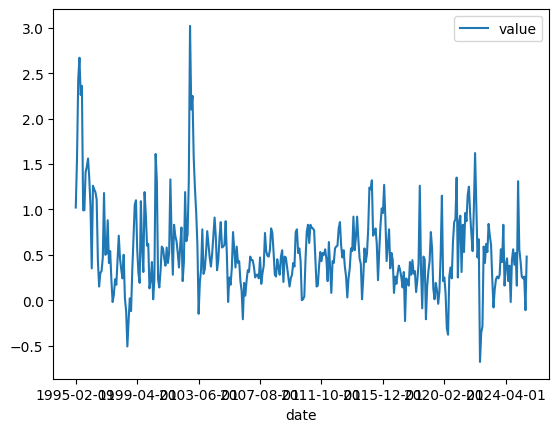

In [108]:
code = '433'
mask = df['name'] == codes[str(code)]
mask&= df['date'] > '1995-01-01'
df[mask][['date','value']].set_index('date').plot()
print(codes[str(code)])

## SQLITE


In [ ]:
import sqlite3
import pandas as pd
import matplotlib 

In [ ]:
db_path = r"D:\Fausto Stangler\Documentos\Python\FLY\data\fly.db"
raw = "tbl_statements_raw"
fetched = "tbl_statements_fetched"
stock_quote = "tbl_stock_quote"

In [ ]:
# conecta ao banco
conn = sqlite3.connect(db_path)

# lê a tabela em um DataFrame
df = pd.read_sql(f"SELECT * FROM {stock_quote}", conn)


In [ ]:
ticker = "ALPA3"

mask = df['ticker'] == ticker
df[mask]['close'].plot()

In [ ]:
# fecha a conexão se não precisar mais
conn.close()


## Ratios

### RAW code

In [2]:
import pandas as pd

In [16]:
quotes = pd.read_csv("quotes_ALPA3.csv")
statements = pd.read_csv("statements_con.csv")
indicators = pd.read_csv("indicators_11.csv")

In [17]:
quotes.head(3)

,id,company_name,ticker,date,open,low,high,close,adj_close,volume,currency
0,38409,ALPARGATAS SA,ALPA3,2000-01-03,0.345604,0.345604,0.345604,0.345604,0.237617,332750,BRL
1,38410,ALPARGATAS SA,ALPA3,2000-01-04,0.345604,0.345604,0.345604,0.345604,0.237617,0,BRL
2,38411,ALPARGATAS SA,ALPA3,2000-01-05,0.345604,0.345604,0.345604,0.345604,0.237617,0,BRL


In [18]:
statements.head(3)

,id,nsd,company_name,quarter,version,grupo,quadro,account,description,value,version_numeric
0,152905,6003,ALPARGATAS SA,2010-12-31,2,Dados da Empresa,Composição do Capital,00.01.01,Ações ON Circulação,181524000.0,2
1,152906,6003,ALPARGATAS SA,2010-12-31,2,Dados da Empresa,Composição do Capital,00.01.02,Ações PN Circulação,171932000.0,2
2,152907,6003,ALPARGATAS SA,2010-12-31,2,Dados da Empresa,Composição do Capital,00.02.01,Ações ON Tesouraria,0.0,2


In [19]:
indicators.head(3)

,date,Taxa - Selic (BCB-Demab)
0,1986-06-04,0.065041
1,1986-06-05,0.067397
2,1986-06-06,0.066740


In [47]:
# 1) calendário de referência
q = quotes.copy()
q["date"] = pd.to_datetime(q["date"])
q = q.sort_values("date").drop_duplicates(subset=["date"]).set_index("date")
q

,id,company_name,ticker,open,low,high,close,adj_close,volume,currency
date,,,,,,,,,,
2000-01-03,38409,ALPARGATAS SA,ALPA3,0.345604,0.345604,0.345604,0.345604,0.237617,332750,BRL
2000-01-04,38410,ALPARGATAS SA,ALPA3,0.345604,0.345604,0.345604,0.345604,0.237617,0,BRL
2000-01-05,38411,ALPARGATAS SA,ALPA3,0.345604,0.345604,0.345604,0.345604,0.237617,0,BRL
2000-01-06,38412,ALPARGATAS SA,ALPA3,0.345604,0.345604,0.345604,0.345604,0.237617,0,BRL
2000-01-07,38413,ALPARGATAS SA,ALPA3,0.315552,0.315552,0.315552,0.315552,0.216955,3327,BRL
...,...,...,...,...,...,...,...,...,...,...
2025-10-06,2075104,ALPARGATAS SA,ALPA3,9.690000,9.470000,9.730000,9.470000,9.470000,8500,BRL
2025-10-07,2075105,ALPARGATAS SA,ALPA3,9.580000,9.470000,9.690000,9.550000,9.550000,3400,BRL
2025-10-08,2075106,ALPARGATAS SA,ALPA3,9.550000,9.390000,9.550000,9.390000,9.390000,1800,BRL


In [21]:
calendar = pd.DataFrame({"date": q.index}).set_index("date")
calendar

""
date
2000-01-03
2000-01-04
2000-01-05
2000-01-06
2000-01-07
...
2025-10-06
2025-10-07
2025-10-08


In [42]:
# 2.1) preparando statements
key_columns = ["company_name", "quarter", "grupo", "quadro", "account"]
s = statements.copy()
s["account_description"] = s["account"].str.cat(s["description"], sep=" - ")
s["quarter"] = pd.to_datetime(s["quarter"])
s = s.sort_values(key_columns)
s = s.drop_duplicates(subset=key_columns, keep="last")
statements_wide = s.pivot_table(index="quarter",
                        columns="account_description",  # use "description" se preferir nomes
                        values="value",
                        aggfunc="last").sort_index()
statements_wide.columns.name = None
# statements_wide['01 - Ativo Total']/statements_wide["02 - Passivo Total"]
cutoff = pd.to_datetime(statements_wide.index.min())
statements_wide


,00.01.01 - Ações ON Circulação,00.01.02 - Ações PN Circulação,00.02.01 - Ações ON Tesouraria,00.02.02 - Ações PN Tesouraria,01 - Ativo Total,01.01 - Ativo Circulante de Curto Prazo,01.01.01 - Caixa e Equivalentes de Caixa de Curto Prazo,01.01.02 - Aplicações Financeiras de Curto Prazo,01.01.02.01 - Aplicações a Valor Justo de Curto Prazo,01.01.02.02 - Aplicações ao Custo Amortizado de Curto Prazo,...,07.08.03.01 - Juros,07.08.03.02 - Aluguéis,07.08.03.03 - Outras,07.08.04 - Remuneração de Capitais Próprios,07.08.04.01 - Juros sobre o Capital Próprio,07.08.04.02 - Dividendos,07.08.04.03 - Lucros Retidos / Prejuízo do Período,07.08.04.04 - Part. Não Controladores nos Lucros Retidos,07.08.05 - Outros,07.08.05.09 - Outros
quarter,,,,,,,,,,,,,,,,,,,,,
2010-12-31,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,4.824880e+08,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,3.104520e+08,63412000.0,0.0,2.429290e+08,4111000.0,0.0,0.0
2011-03-31,181524000.0,171932000.0,0.0,5093000.0,2.327149e+09,1.532590e+09,3.706080e+08,289582000.0,0.0,289582000.0,...,8669000.0,5310000.0,5510000.0,8.850300e+07,19500000.0,0.0,6.775100e+07,1252000.0,0.0,0.0
2011-06-30,181524000.0,171932000.0,0.0,5093000.0,2.309312e+09,1.527163e+09,2.843980e+08,382047000.0,0.0,382047000.0,...,17580000.0,5929000.0,6172000.0,7.390900e+07,20000000.0,0.0,5.386200e+07,47000.0,0.0,0.0
2011-09-30,181524000.0,171932000.0,0.0,5093000.0,2.465966e+09,1.643157e+09,2.703270e+08,413378000.0,0.0,413378000.0,...,17570000.0,6820000.0,7189000.0,8.786800e+07,20600000.0,0.0,6.688300e+07,385000.0,0.0,0.0
2011-12-31,181524000.0,171932000.0,0.0,5093000.0,2.442554e+09,1.609539e+09,5.104670e+08,160487000.0,0.0,160487000.0,...,18472000.0,8960000.0,5684000.0,5.878700e+07,18500000.0,0.0,4.032400e+07,-37000.0,0.0,0.0
2012-03-31,181524000.0,171932000.0,0.0,5093000.0,2.516935e+09,1.670648e+09,5.073120e+08,173368000.0,0.0,173368000.0,...,13048000.0,9106000.0,5974000.0,7.824300e+07,21600000.0,0.0,5.656500e+07,78000.0,0.0,0.0
2012-06-30,199676000.0,189125000.0,0.0,5603000.0,2.613403e+09,1.776588e+09,4.663320e+08,155139000.0,0.0,155139000.0,...,20283000.0,8160000.0,8725000.0,6.191000e+07,21800000.0,0.0,3.963800e+07,472000.0,0.0,0.0
2012-09-30,199676000.0,189125000.0,0.0,5603000.0,2.758140e+09,1.887720e+09,5.278090e+08,132487000.0,0.0,132487000.0,...,14727000.0,8676000.0,10815000.0,7.411300e+07,20600000.0,0.0,5.346000e+07,53000.0,0.0,0.0
2012-12-31,199676000.0,189125000.0,0.0,5603000.0,2.740729e+09,1.838987e+09,1.228300e+08,494078000.0,0.0,494078000.0,...,13613000.0,9451000.0,11874000.0,6.627000e+07,21000000.0,25300000.0,2.002000e+07,-50000.0,0.0,0.0


In [ ]:
# 2.2) statements trimestrais ancorados no fim do trimestre
s = pd.merge_asof(
    calendar[calendar.index >= cutoff],
    statements_wide,
    left_index=True,
    right_index=True,
    direction="backward"
)
# opcional: se o calendário começa antes do primeiro quarter, cobre só o início
if s.iloc[0].isna().any():
    s = s.bfill()
s

,00.01.01 - Ações ON Circulação,00.01.02 - Ações PN Circulação,00.02.01 - Ações ON Tesouraria,00.02.02 - Ações PN Tesouraria,01 - Ativo Total,01.01 - Ativo Circulante de Curto Prazo,01.01.01 - Caixa e Equivalentes de Caixa de Curto Prazo,01.01.02 - Aplicações Financeiras de Curto Prazo,01.01.02.01 - Aplicações a Valor Justo de Curto Prazo,01.01.02.02 - Aplicações ao Custo Amortizado de Curto Prazo,...,07.08.03.01 - Juros,07.08.03.02 - Aluguéis,07.08.03.03 - Outras,07.08.04 - Remuneração de Capitais Próprios,07.08.04.01 - Juros sobre o Capital Próprio,07.08.04.02 - Dividendos,07.08.04.03 - Lucros Retidos / Prejuízo do Período,07.08.04.04 - Part. Não Controladores nos Lucros Retidos,07.08.05 - Outros,07.08.05.09 - Outros
date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-04,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-05,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-06,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-07,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-06,339510689.0,343551533.0,32.0,5251413.0,6.194674e+09,3.031060e+09,864577000.0,0.0,0.0,0.0,...,58260000.0,6246000.0,6865000.0,86956000.0,0.0,0.0,87892000.0,-936000.0,0.0,0.0
2025-10-07,339510689.0,343551533.0,32.0,5251413.0,6.194674e+09,3.031060e+09,864577000.0,0.0,0.0,0.0,...,58260000.0,6246000.0,6865000.0,86956000.0,0.0,0.0,87892000.0,-936000.0,0.0,0.0
2025-10-08,339510689.0,343551533.0,32.0,5251413.0,6.194674e+09,3.031060e+09,864577000.0,0.0,0.0,0.0,...,58260000.0,6246000.0,6865000.0,86956000.0,0.0,0.0,87892000.0,-936000.0,0.0,0.0


In [44]:
indicators

,date,Taxa - Selic (BCB-Demab)
0,1986-06-04,0.065041
1,1986-06-05,0.067397
2,1986-06-06,0.066740
3,1986-06-09,0.068247
4,1986-06-10,0.067041
...,...,...
9862,2025-10-06,0.055131
9863,2025-10-07,0.055131
9864,2025-10-08,0.055131
9865,2025-10-09,0.055131


In [45]:
# 3.1) indicadores com frequências mistas
indicators_wide = indicators.copy()
indicators_wide["date"] = pd.to_datetime(indicators_wide["date"])
indicators_wide = indicators_wide.sort_values("date").drop_duplicates(subset=["date"]).set_index("date")


In [46]:
# 3.2) merge_asof (robusto para chaves não idênticas)
i = pd.merge_asof(
    calendar[calendar.index >= cutoff],
    indicators_wide,
    left_index=True,
    right_index=True,
    direction="backward"
    )
# opcional: se o calendário começa antes do primeiro quarter, cobre só o início
if i.iloc[0].isna().any():
    i = i.bfill()
i

,Taxa - Selic (BCB-Demab)
date,
2011-01-03,0.040239
2011-01-04,0.040203
2011-01-05,0.040239
2011-01-06,0.040203
2011-01-07,0.040239
...,...
2025-10-06,0.055131
2025-10-07,0.055131
2025-10-08,0.055131


In [48]:
q = q[q.index >= cutoff]
q

,id,company_name,ticker,open,low,high,close,adj_close,volume,currency
date,,,,,,,,,,
2011-01-03,41209,ALPARGATAS SA,ALPA3,6.371149,6.371149,6.479338,6.473328,5.055120,4658,BRL
2011-01-04,41210,ALPARGATAS SA,ALPA3,6.473328,6.473328,6.473328,6.473328,5.055120,1331,BRL
2011-01-05,41211,ALPARGATAS SA,ALPA3,6.473328,6.311044,6.473328,6.311044,4.928391,1497,BRL
2011-01-06,41212,ALPARGATAS SA,ALPA3,6.551465,6.551465,6.551465,6.551465,5.116141,2662,BRL
2011-01-07,41213,ALPARGATAS SA,ALPA3,6.551465,6.551465,6.551465,6.551465,5.116141,665,BRL
...,...,...,...,...,...,...,...,...,...,...
2025-10-06,2075104,ALPARGATAS SA,ALPA3,9.690000,9.470000,9.730000,9.470000,9.470000,8500,BRL
2025-10-07,2075105,ALPARGATAS SA,ALPA3,9.580000,9.470000,9.690000,9.550000,9.550000,3400,BRL
2025-10-08,2075106,ALPARGATAS SA,ALPA3,9.550000,9.390000,9.550000,9.390000,9.390000,1800,BRL


In [ ]:
i

,Taxa - Selic (BCB-Demab)
date,
2011-01-03,0.040239
2011-01-04,0.040203
2011-01-05,0.040239
2011-01-06,0.040203
2011-01-07,0.040239
...,...
2025-10-06,0.055131
2025-10-07,0.055131
2025-10-08,0.055131


<Axes: xlabel='date'>

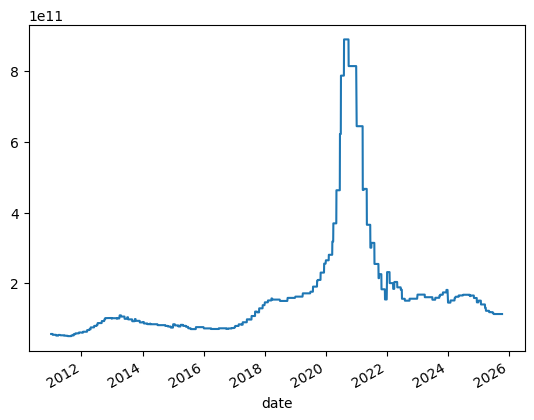

In [56]:
q.to_csv('df_q.csv')
s.to_csv('df_s.csv')
i.to_csv('df_i.csv')
r = pd.DataFrame()
r['ROE'] = s['01 - Ativo Total'] / i['Taxa - Selic (BCB-Demab)']
r['ROE'].plot()

<Axes: xlabel='date'>

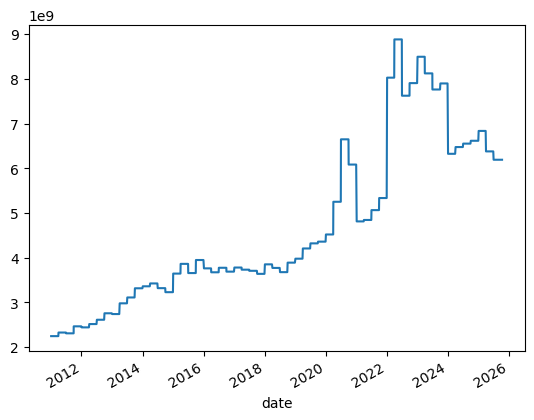

In [60]:
s['01 - Ativo Total'].plot()

### Métodos FLY

In [77]:
import datetime
import pandas as pd

In [156]:
raw_quotes = pd.read_csv("quotes_ALPA3.csv")
raw_statements = pd.read_csv("statements_con.csv")
raw_indicators = pd.read_csv("indicators_11.csv")

In [ ]:
def _treat_quotes(q, cutoff=None):
    if not cutoff:
        cutoff = datetime.datetime(year=2010, month=12, day=31)

    q["date"] = pd.to_datetime(q["date"])
    q = q.sort_values("date").drop_duplicates(subset=["date"]).set_index("date")
    if cutoff:
        q = q[q.index >= cutoff]
    return q

In [ ]:
def _treat_statements(s, c):
    if c.empty:
        return pd.DataFrame()

    key_columns = ["company_name", "quarter", "grupo", "quadro", "account"]
    s["account_description"] = s["account"].str.cat(s["description"], sep=" - ")
    s["quarter"] = pd.to_datetime(s["quarter"])
    s = s.sort_values(key_columns)
    s = s.drop_duplicates(subset=key_columns, keep="last")
    statements_wide = s.pivot_table(index="quarter",
                            columns="account_description",  # use "description" se preferir nomes ou "account" se preferir contas
                            values="value",
                            aggfunc="last").sort_index()
    statements_wide.columns.name = None

    s = statements_wide.sort_index().reindex(c.index, method="ffill")
    if s.iloc[0].isna().any():
        s = s.bfill()

    return s


In [142]:
def _indicators(i, c):
    if c.empty:
        return pd.DataFrame()

    indicators_wide = indicators.copy()
    indicators_wide["date"] = pd.to_datetime(indicators_wide["date"])
    indicators_wide = indicators_wide.sort_values("date").drop_duplicates(subset=["date"]).set_index("date")

    i = indicators_wide.sort_index().reindex(c.index, method="ffill")
    if i.iloc[0].isna().any():
        i = i.bfill()

    return i

'2010-12-31'

In [165]:
cutoff = datetime.datetime(year=2024, month=12, day=31)
cutoff = raw_statements['quarter'].min()

q = _quotes(raw_quotes, cutoff)
s = _statements(raw_statements, q)
i = _indicators(raw_indicators, q)


In [168]:
s

,00.01.01 - Ações ON Circulação,00.01.02 - Ações PN Circulação,00.02.01 - Ações ON Tesouraria,00.02.02 - Ações PN Tesouraria,01 - Ativo Total,01.01 - Ativo Circulante de Curto Prazo,01.01.01 - Caixa e Equivalentes de Caixa de Curto Prazo,01.01.02 - Aplicações Financeiras de Curto Prazo,01.01.02.01 - Aplicações a Valor Justo de Curto Prazo,01.01.02.02 - Aplicações ao Custo Amortizado de Curto Prazo,...,07.08.03.01 - Juros,07.08.03.02 - Aluguéis,07.08.03.03 - Outras,07.08.04 - Remuneração de Capitais Próprios,07.08.04.01 - Juros sobre o Capital Próprio,07.08.04.02 - Dividendos,07.08.04.03 - Lucros Retidos / Prejuízo do Período,07.08.04.04 - Part. Não Controladores nos Lucros Retidos,07.08.05 - Outros,07.08.05.09 - Outros
date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-04,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-05,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-06,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-07,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-06,339510689.0,343551533.0,32.0,5251413.0,6.194674e+09,3.031060e+09,864577000.0,0.0,0.0,0.0,...,58260000.0,6246000.0,6865000.0,86956000.0,0.0,0.0,87892000.0,-936000.0,0.0,0.0
2025-10-07,339510689.0,343551533.0,32.0,5251413.0,6.194674e+09,3.031060e+09,864577000.0,0.0,0.0,0.0,...,58260000.0,6246000.0,6865000.0,86956000.0,0.0,0.0,87892000.0,-936000.0,0.0,0.0
2025-10-08,339510689.0,343551533.0,32.0,5251413.0,6.194674e+09,3.031060e+09,864577000.0,0.0,0.0,0.0,...,58260000.0,6246000.0,6865000.0,86956000.0,0.0,0.0,87892000.0,-936000.0,0.0,0.0
